# **Importing and Data Fetching**

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures as pol
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
import seaborn as sns

In [28]:
df = pd.read_csv("../../../Data/Ice_cream Polynomial.csv")
df.sample()

,Temperature (°C),Ice Cream Sales (units)
44,3.610778,28.912188


# **Information about Dataset**

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 916.0 bytes


In [30]:
df.shape

(49, 2)

In [31]:
df.isnull().sum()

Temperature (°C)           0
Ice Cream Sales (units)    0
dtype: int64

In [32]:
df.corr()

,Temperature (°C),Ice Cream Sales (units)
Temperature (°C),1.000000,-0.175184
Ice Cream Sales (units),-0.175184,1.000000


# **Ploting Graph**

<Axes: xlabel='Temperature (°C)', ylabel='Ice Cream Sales (units)'>

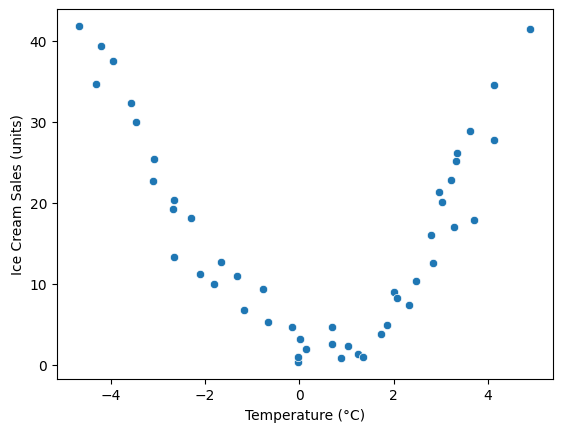

In [33]:
sns.scatterplot(x=df["Temperature (°C)"], y=df["Ice Cream Sales (units)"],)

# **Train Test Split**

In [34]:
Xtrain, Xtest, ytrain, ytest = train_test_split(df[["Temperature (°C)"]], df["Ice Cream Sales (units)"],test_size=0.8, random_state=42)

# **Creating Model**

In [35]:
model = LinearRegression()

In [36]:
model.fit(Xtrain, ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# **Model Prediction with Linear Regression**

In [37]:
ypred = model.predict(Xtest)

# **Ploting Graph**

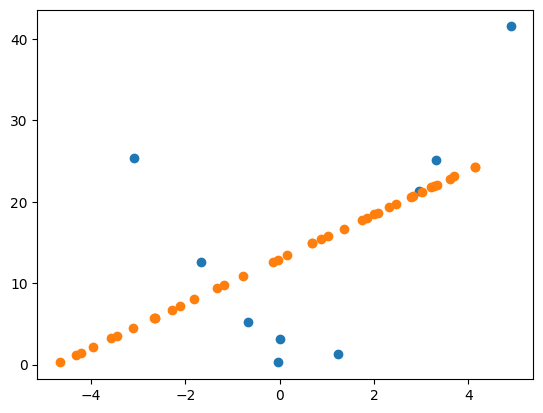

In [38]:
plt.scatter(x=Xtrain, y=ytrain)
plt.scatter(x=Xtest, y=ypred)

# **Conclusion**

## Linear Regression can't predict Non Linear Data
## This has more outlayer and can't predict accurate data
---



# **Polynomial**

### Creating Object of polynomial

In [39]:
ploy = pol(degree=6)

### Traning data to ploynomial

In [40]:
updated_X = ploy.fit_transform(Xtrain)
updated_X_test = ploy.fit_transform(Xtest)

---
# **Creation Linear Regression**

In [41]:
model = LinearRegression()

# **Model Traning with new values**

In [42]:
model.fit(updated_X, ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# **Predicting Values**

In [43]:
yPred = model.predict(updated_X)

# **Ploting graph to check accuracy**

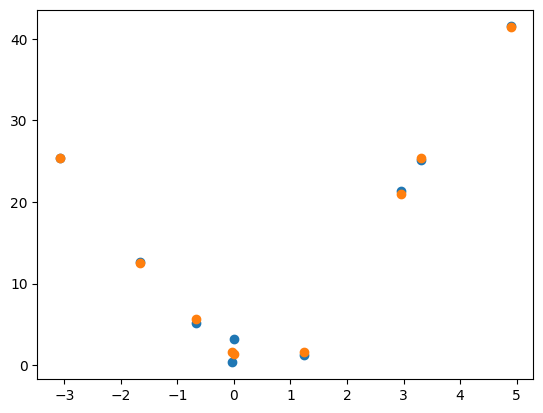

In [44]:
plt.scatter(Xtrain, ytrain)
plt.scatter(Xtrain, yPred)

# **Ploting graph to check accuracy**

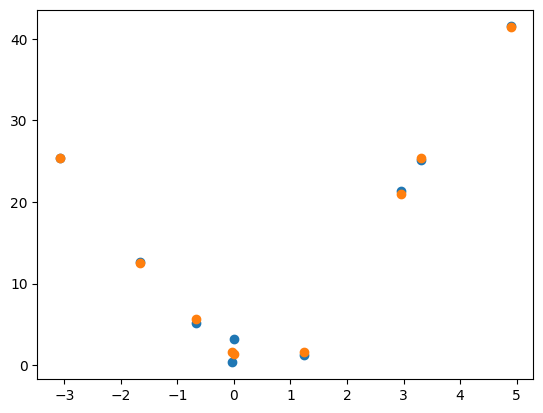

In [45]:
plt.scatter(updated_X[:,1], ytrain)
plt.scatter(updated_X[:,1], yPred)

In [46]:
Y_test_pre = model.predict(updated_X_test)

# **Accuray for the model**

In [47]:
r2_score(ytrain, yPred),r2_score(ytest, Y_test_pre)

(0.9966303318847589, -2.9456070665922383)

Degree = 2 

0.9554388710207391, 0.9036676639830425

Degree = 3

0.9665997105174636, 0.7532015688032727

Degree = 4

0.9946020525923618, 0.6043811071160776

Degree = 5

0.9959433388296356, 0.8752547869099822

Degree = 6

0.9966303318847589, -2.9456070665922383